# scitex-ml — Classification Quick Start

Minimal walk-through of `scitex_ml.Classifier` — a thin factory over scikit-learn estimators that integrates with `ClassificationReporter` for metric tracking and figure export.

**What this notebook covers**

1. Train a `Classifier`-built estimator on the Iris dataset.
2. Score on a held-out test split.
3. Use `ClassificationReporter` to compute and persist metrics.

Heavy / optional dependencies (`torch`, `optuna`, `pytorch_pretrained_vit`) are not required for this notebook.

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import scitex_ml
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

scitex_ml.__version__

'0.1.0'

## 1. Train / evaluate

`Classifier` is a factory: instantiate it once, then call to materialise a fresh scikit-learn estimator by name.

In [2]:
X, y = load_iris(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, random_state=0, stratify=y)

factory = scitex_ml.Classifier()
clf = factory('LogisticRegression')
clf.fit(X_tr, y_tr)
score = clf.score(X_te, y_te)
print(f'test accuracy: {score:.3f}')
print('available estimators:', factory.list[:6], '...')

test accuracy: 1.000
available estimators: ['Perceptron', 'PassiveAggressiveClassifier', 'LogisticRegression', 'SGDClassifier', 'RidgeClassifier', 'QuadraticDiscriminantAnalysis'] ...


## 2. Metric reporting

`ClassificationReporter` computes balanced-accuracy, MCC, confusion matrix, ROC-AUC + curve, and PR-AUC + curve, and persists them to `output_dir`.

INFO: Config set as:
INFO:     precision: 3
INFO:     required_metrics:
INFO:         balanced_accuracy
INFO:         mcc
INFO:         confusion_matrix
INFO:         classification_report
INFO:         roc_auc
INFO:         roc_curve
INFO:         pre_rec_auc
INFO:         pre_rec_curve



INFO: Classification reporter initialized (output directory: /home/ywatanabe/.cache/tmp/tmp3stpkmaq)


INFO: Classification reporter initialized (output directory: /home/ywatanabe/.cache/tmp/tmp3stpkmaq)


SUCC: Saved to: ./../../../.cache/tmp/tmp3stpkmaq/config.json (326.00 B)


INFO: Saved to: /home/ywatanabe/.cache/tmp/tmp3stpkmaq/config.json


...

SUCC: Saved to: ./../../../.cache/tmp/tmp3stpkmaq/fold_00/fold-00_y-pred.csv (281.00 B)


INFO: Saved to: /home/ywatanabe/.cache/tmp/tmp3stpkmaq/fold_00/fold-00_y-pred.csv


SUCC: Saved to: ./../../../.cache/tmp/tmp3stpkmaq/fold_00/fold-00_y-proba.csv (2.50 KB)


INFO: Saved to: /home/ywatanabe/.cache/tmp/tmp3stpkmaq/fold_00/fold-00_y-proba.csv






summary keys: ['output_dir', 'total_folds', 'metrics_summary', 'overall_confusion_matrix', 'overall_confusion_matrix_normalized']


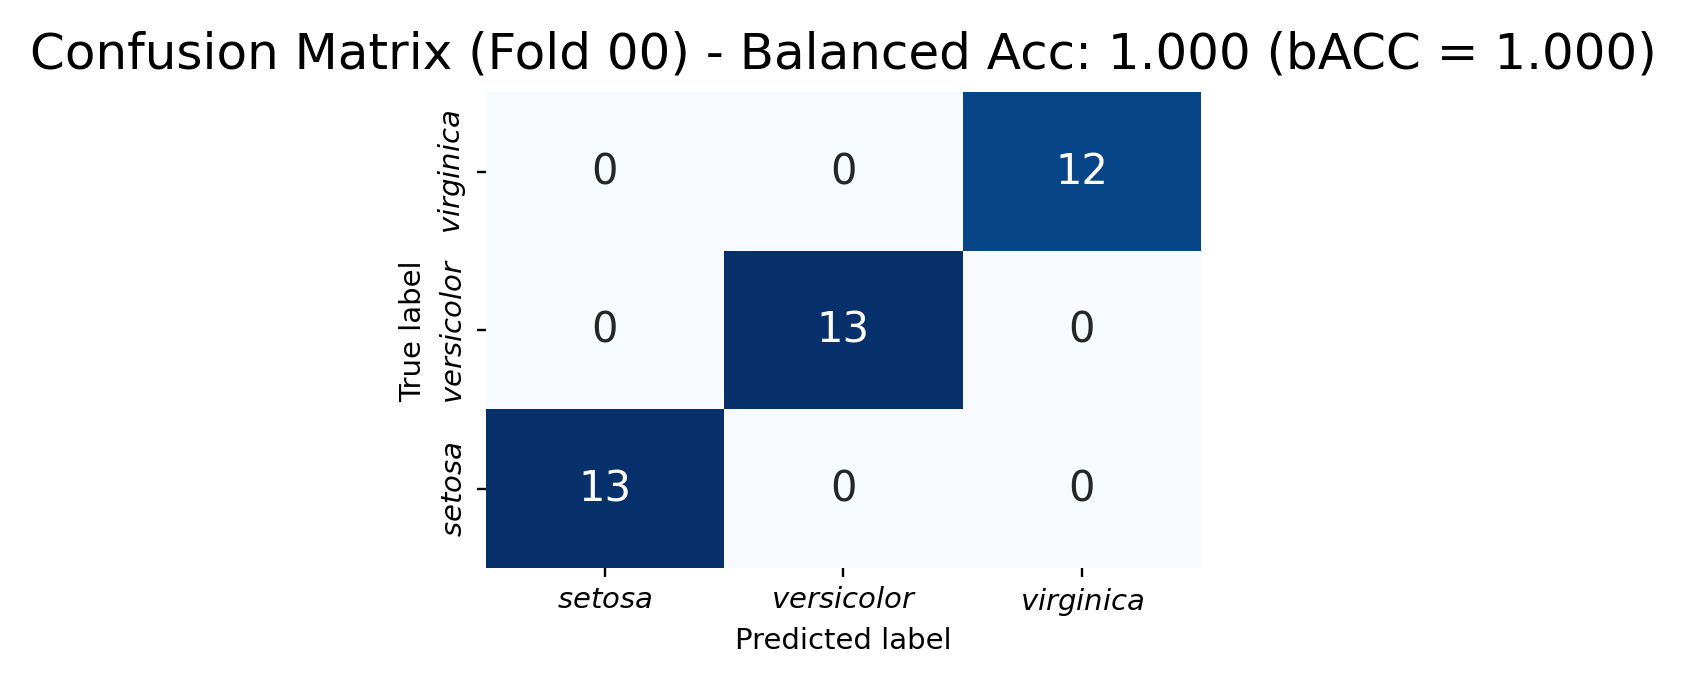

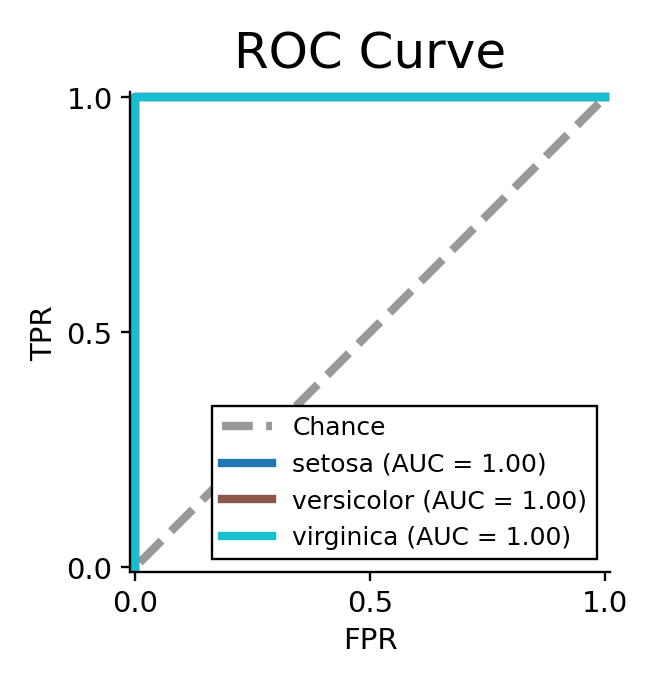

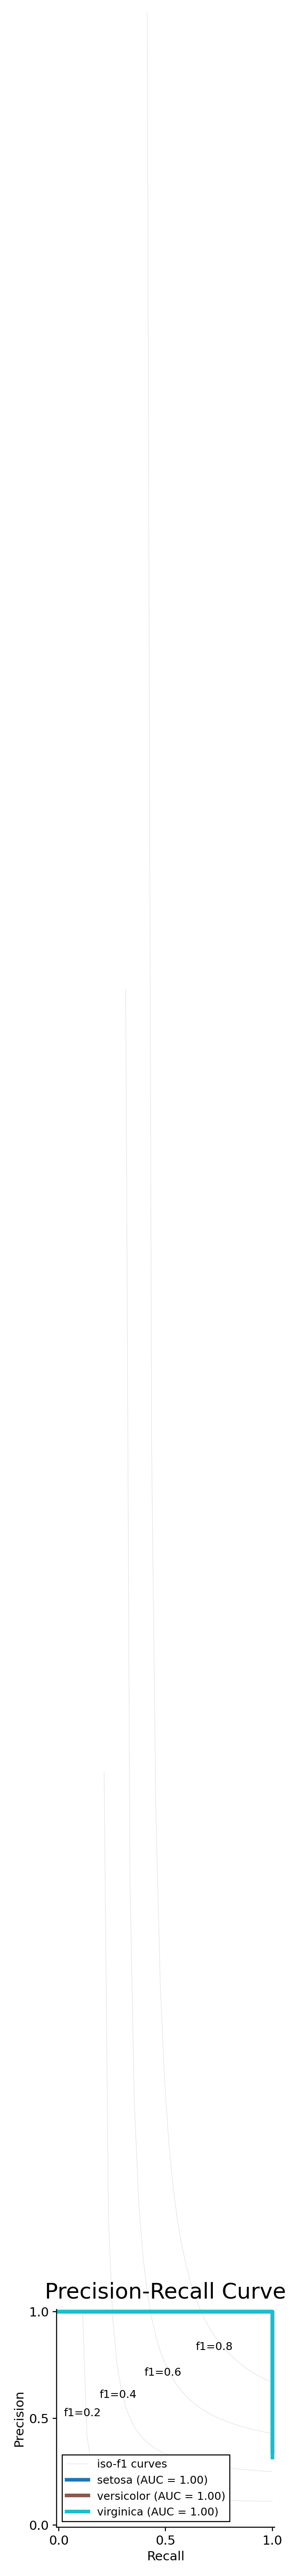

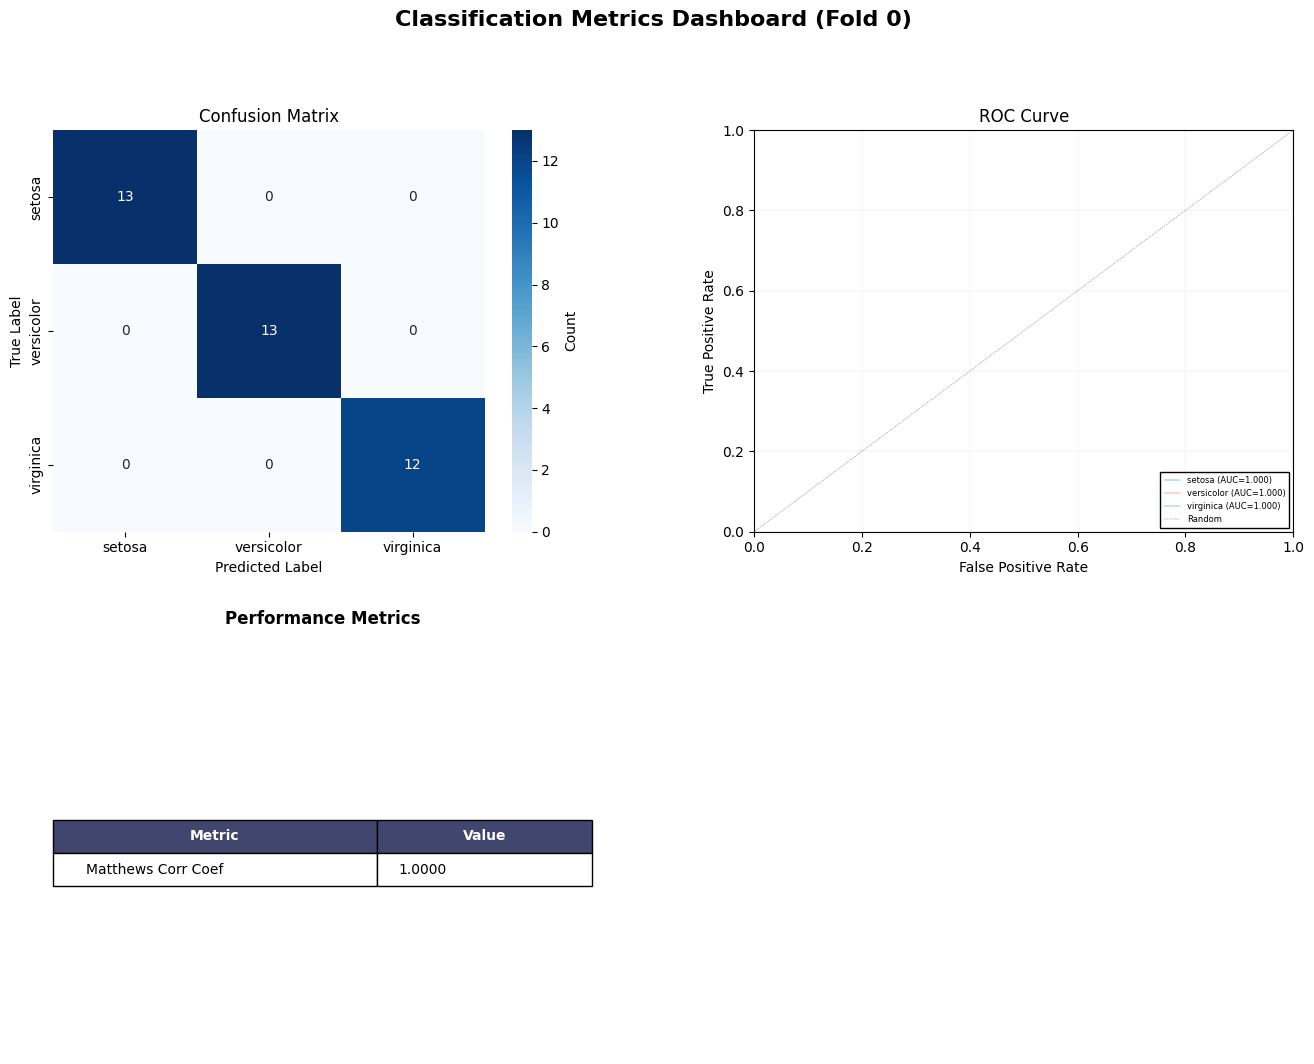

In [3]:
import tempfile
from pathlib import Path

with tempfile.TemporaryDirectory() as tmp:
    reporter = scitex_ml.ClassificationReporter(output_dir=tmp)
    y_pred = clf.predict(X_te)
    y_proba = clf.predict_proba(X_te)
    reporter.calculate_metrics(
        y_true=y_te,
        y_pred=y_pred,
        y_proba=y_proba,
        labels=['setosa', 'versicolor', 'virginica'],
    )
    print('summary keys:', list(reporter.get_summary().keys())[:8])

## Where to next

- `scitex_ml.classification` — time-series CV splitters (`TimeSeriesStratifiedSplit`, `TimeSeriesSlidingWindowSplit`, `TimeSeriesBlockingSplit`, `TimeSeriesCalendarSplit`).
- `scitex_ml.training` — `EarlyStopping`, `LearningCurveLogger`.
- `scitex_ml.optim` — `get_optimizer` / `set_optimizer` shortcuts; vendored Ranger.
- `scitex_ml.metrics` — `calc_bacc`, `calc_conf_mat`, `calc_roc_auc`.

For generative-AI (LLM, agent, image, audio) see `scitex-genai`.